# Universal EDA — reusable functions, showcased on 3 datasets

All logic lives in `src/ml_boilerplate/eda_universal.py` — one importable function per task (tables return DataFrames/dicts, charts return matplotlib Figures). This notebook is a thin showcase: **Dataset A** (Auto MPG, regression + missingness), **Dataset B** (Penguins, 3-class classification), **Dataset C** (Sunspots, time-aware). Same function calls on each — compare the outputs.

Your own data: `findings = run_universal_eda(my_df, target="...", date="...")` (see §5). Outputs below are baked in — Run All to reproduce.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml_boilerplate.eda_universal import (
    categorical_columns, categorical_top, categorical_vs_target, column_profile,
    detect_datetime_columns, detect_task, datetime_summary, encoding_advice,
    fig_boxplots, fig_heatmap, fig_histograms, fig_missing_bar,
    fig_target_distribution, leakage_suspects, missing_summary,
    missing_target_signal, multicollinear_pairs, numeric_describe,
    numeric_vs_target, outlier_shares, quality_flags, run_universal_eda,
    target_correlations, target_stats, volume_trend, zero_shares,
)
from ml_boilerplate.io import read_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
print("imports ok")

imports ok


## 1 — Load helper
One task: define `load_sample()` for the vendored offline CSVs.

In [2]:
def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "mpg.csv").exists():
            return p
    return Path(".")

def load_sample(name):
    files = {"mpg": "data/mpg.csv", "penguins": "data/penguins.csv",
             "sunspots": "data/monthly-sunspots.csv"}
    df = read_table(str(repo_root() / files[name]))
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    return df

## 2 — Load the three showcase datasets (one task per cell)

In [3]:
mpg_df = load_sample("mpg")
MPG_TARGET = "mpg"

mpg: 398 rows x 9 cols


In [4]:
penguins_df = load_sample("penguins")
PENGUINS_TARGET = "species"

penguins: 344 rows x 7 cols


In [5]:
sunspots_df = load_sample("sunspots")
SUNSPOTS_TARGET = "Sunspots"
SUNSPOTS_DATE = "Month"

sunspots: 2,820 rows x 2 cols


## 3 — The one-call driver
One task: `run_universal_eda()` runs every check and returns a findings dict.

In [6]:
findings = run_universal_eda(mpg_df, target=MPG_TARGET)
print("task:", findings["task"])
print("keys:", sorted(findings.keys()))
print(json.dumps(findings["flags"], indent=2, default=str))
print("-> Use this when you just want answers; the rest of the notebook shows each step.")

task: regression
keys: ['categoricals', 'corr_with_target', 'datetime_columns', 'flags', 'id_cols', 'missing', 'numeric_describe', 'outliers', 'profile', 'shape', 'target_stats', 'task', 'zeros']
{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [
    [
      "cylinders",
      "displacement",
      0.951
    ],
    [
      "cylinders",
      "horsepower",
      0.843
    ],
    [
      "cylinders",
      "weight",
      0.896
    ],
    [
      "displacement",
      "horsepower",
      0.897
    ],
    [
      "displacement",
      "weight",
      0.933
    ],
    [
      "horsepower",
      "weight",
      0.865
    ]
  ],
  "task": "regression",
  "target": "mpg"
}
-> Use this when you just want answers; the rest of the notebook shows each step.


## Dataset A — Auto MPG (regression, 398 rows, 6 missing horsepower)
Same calls as B and C — watch how the outputs differ.

### A1 — Column profile: `column_profile()`

In [7]:
display(column_profile(mpg_df))

,dtype,pct_missing,n_unique,is_constant,is_id_like
mpg,float64,0.00,129,False,False
cylinders,int64,0.00,5,False,False
displacement,float64,0.00,82,False,False
horsepower,float64,1.51,94,False,False
weight,int64,0.00,351,False,False
acceleration,float64,0.00,95,False,False
model_year,int64,0.00,13,False,False
origin,str,0.00,3,False,False
name,str,0.00,305,False,False


### A2 — Missing counts: `missing_summary()`

In [8]:
display(missing_summary(mpg_df))
print("-> Say: only horsepower is missing (6 rows) — MCAR-looking, plain impute is fine.")

,pct_missing,n_missing
horsepower,1.51,6


-> Say: only horsepower is missing (6 rows) — MCAR-looking, plain impute is fine.


### A3 — Missing chart: `fig_missing_bar()`

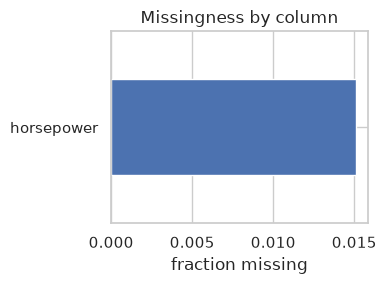

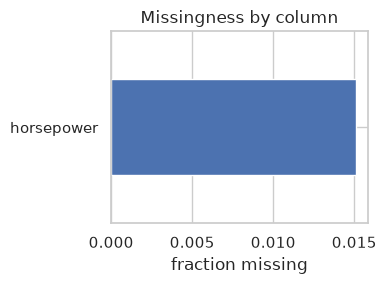

In [9]:
fig_missing_bar(mpg_df)

### A4 — Is missingness predictive? `missing_target_signal()`

In [10]:
print(missing_target_signal(mpg_df, "horsepower", MPG_TARGET))
print("-> mean(mpg|missing) ~= mean(mpg|present): missingness carries no signal here.")

{'n_missing': 6, 'mean_target_missing': 28.0, 'mean_target_present': 23.445918367346938}
-> mean(mpg|missing) ~= mean(mpg|present): missingness carries no signal here.


### A5 — Numeric shape: `numeric_describe()`

In [11]:
display(numeric_describe(mpg_df, exclude=[MPG_TARGET]).round(3))

,count,mean,std,min,25%,50%,75%,max,skew,kurt
cylinders,398.0,5.455,1.701,3.0,4.000,4.0,8.000,8.0,0.527,-1.377
displacement,398.0,193.426,104.270,68.0,104.250,148.5,262.000,455.0,0.720,-0.747
horsepower,392.0,104.469,38.491,46.0,75.000,93.5,126.000,230.0,1.087,0.697
weight,398.0,2970.425,846.842,1613.0,2223.750,2803.5,3608.000,5140.0,0.531,-0.786
acceleration,398.0,15.568,2.758,8.0,13.825,15.5,17.175,24.8,0.279,0.419
model_year,398.0,76.010,3.698,70.0,73.000,76.0,79.000,82.0,0.012,-1.181


### A6 — Distributions: `fig_histograms()`

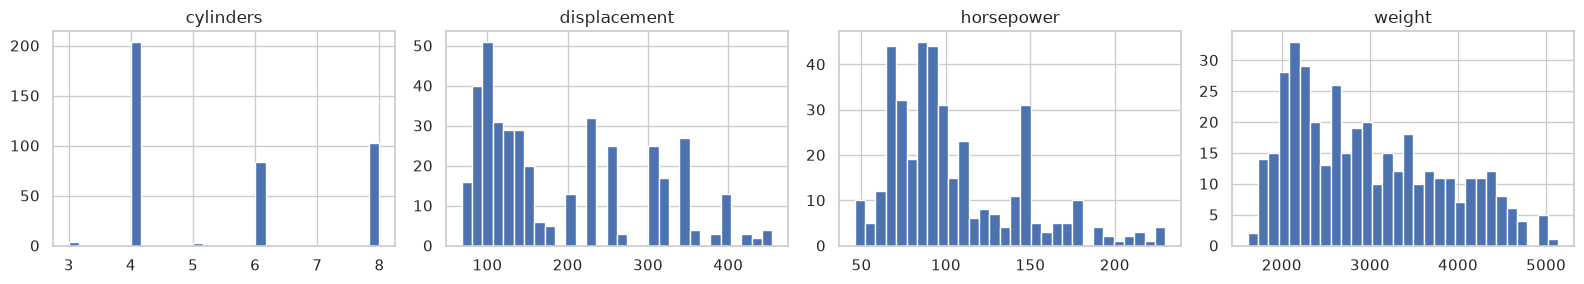

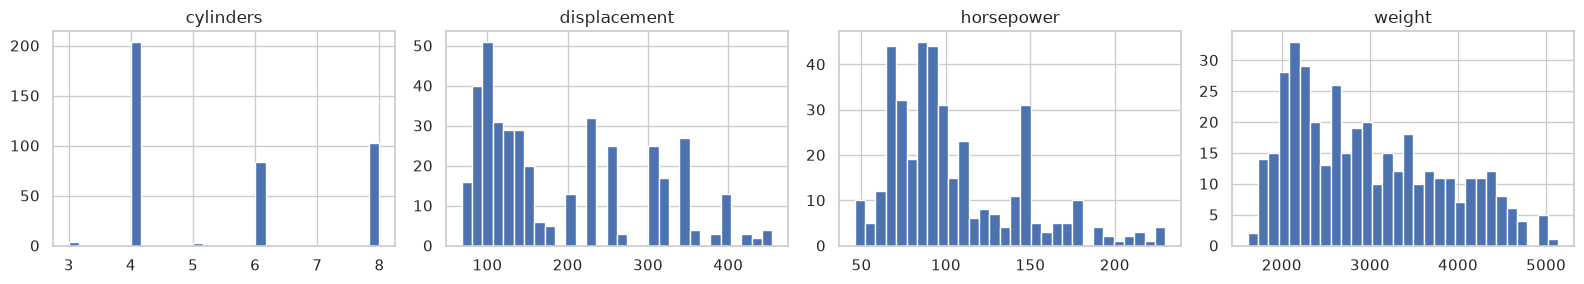

In [12]:
fig_histograms(mpg_df, exclude=[MPG_TARGET])

### A7 — Spread: `fig_boxplots()`

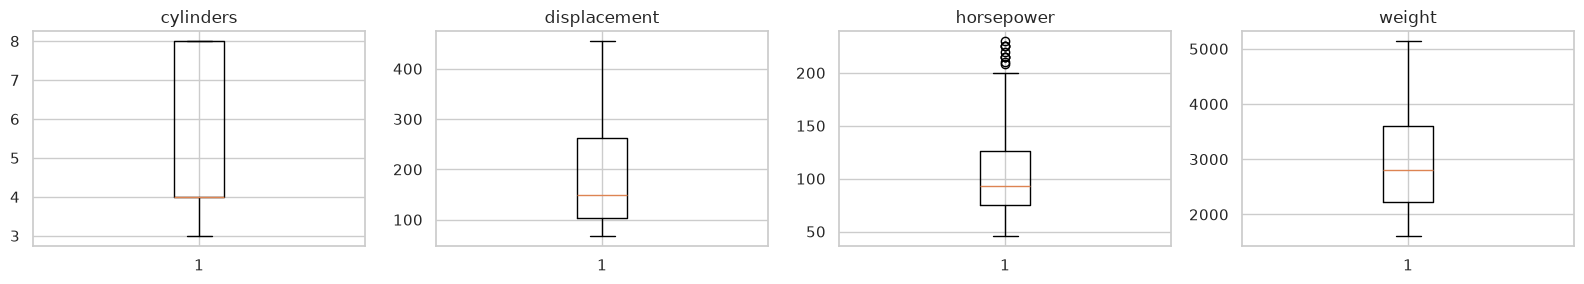

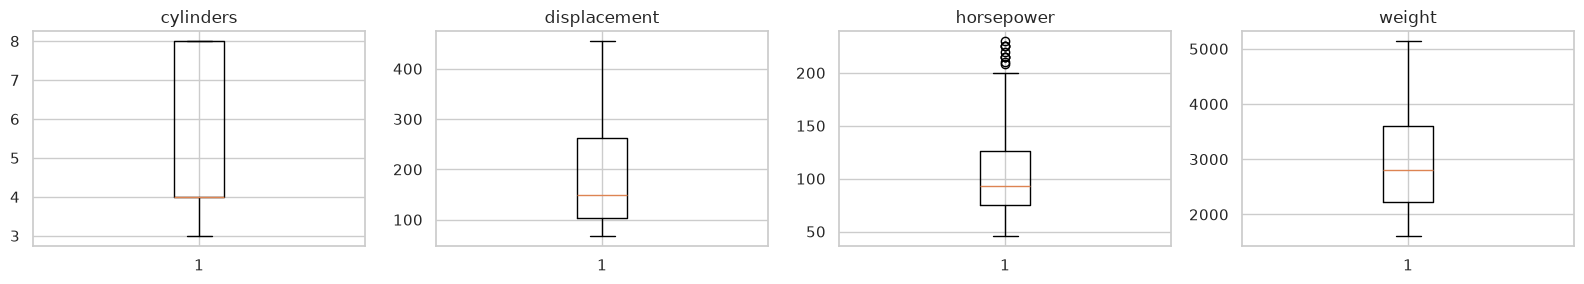

In [13]:
fig_boxplots(mpg_df, exclude=[MPG_TARGET])

### A8 — Outliers and zeros: `outlier_shares()` + `zero_shares()`

In [14]:
print("outliers:", outlier_shares(mpg_df, exclude=[MPG_TARGET]))
print("zeros:", zero_shares(mpg_df, exclude=[MPG_TARGET]))

outliers: {'cylinders': 0.0, 'displacement': 0.0, 'horsepower': 0.0255, 'weight': 0.0, 'acceleration': 0.0176, 'model_year': 0.0}
zeros: {'cylinders': 0.0, 'displacement': 0.0, 'horsepower': 0.0, 'weight': 0.0, 'acceleration': 0.0, 'model_year': 0.0}


### A9 — Categoricals: `categorical_columns()` + `categorical_top()` + `encoding_advice()`

In [15]:
print("categoricals:", categorical_columns(mpg_df, target=MPG_TARGET))
for c in categorical_columns(mpg_df, target=MPG_TARGET)[:3]:
    print(f"--- {c} ---")
    print(categorical_top(mpg_df, c).to_string())
    print("advice:", encoding_advice(mpg_df, c))

categoricals: ['origin', 'name', 'cylinders']
--- origin ---
origin
usa       0.6256
japan     0.1985
europe    0.1759
advice: low cardinality: one-hot encoding is fine
--- name ---
name
ford pinto          0.0151
ford maverick       0.0126
amc matador         0.0126
toyota corolla      0.0126
chevrolet impala    0.0101
advice: high cardinality: target/frequency encoding or hashing, not one-hot
--- cylinders ---
cylinders
4    0.5126
8    0.2588
6    0.2111
3    0.0101
5    0.0075
advice: 1 rare level(s) <1%: group into 'Other'


### A10 — Task + target: `detect_task()` + `target_stats()` + `fig_target_distribution()`

task: regression {'skew': 0.457, 'kurt': -0.511, 'zero_share': 0.0}


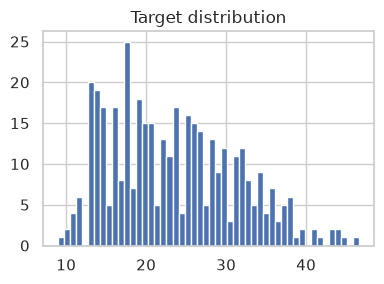

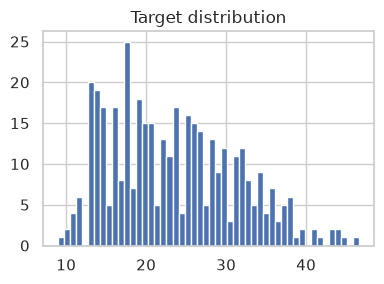

In [16]:
mpg_task = detect_task(mpg_df[MPG_TARGET], has_time=False)
print("task:", mpg_task, target_stats(mpg_df[MPG_TARGET], mpg_task))
fig_target_distribution(mpg_df[MPG_TARGET], mpg_task)

### A11 — Signal ranking: `target_correlations()`

In [17]:
display(target_correlations(mpg_df, MPG_TARGET, mpg_task).round(3).head(8))

weight         -0.832
displacement   -0.804
horsepower     -0.778
cylinders      -0.775
model_year      0.579
acceleration    0.420
Name: mpg, dtype: float64

### A12 — Leakage + collinearity: `leakage_suspects()` + `multicollinear_pairs()`

In [18]:
ct = target_correlations(mpg_df, MPG_TARGET, mpg_task)
print("leakage suspects:", leakage_suspects(ct))
print("multicollinear:", multicollinear_pairs(mpg_df, exclude=[MPG_TARGET]))
print("-> displacement/cylinders/weight correlate ~0.8: drop one, regularize, or PCA.")

leakage suspects: []
multicollinear: [('cylinders', 'displacement', 0.951), ('cylinders', 'horsepower', 0.843), ('cylinders', 'weight', 0.896), ('displacement', 'horsepower', 0.897), ('displacement', 'weight', 0.933), ('horsepower', 'weight', 0.865)]
-> displacement/cylinders/weight correlate ~0.8: drop one, regularize, or PCA.


### A13 — Heatmap: `fig_heatmap()`

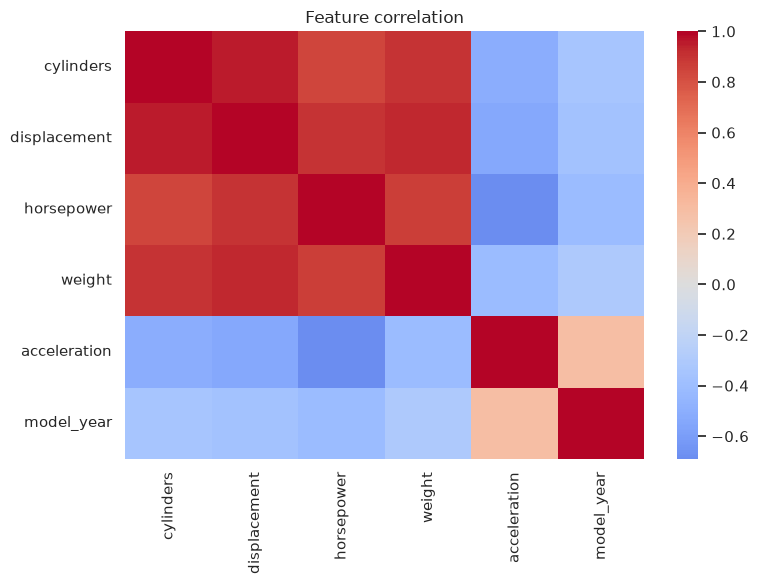

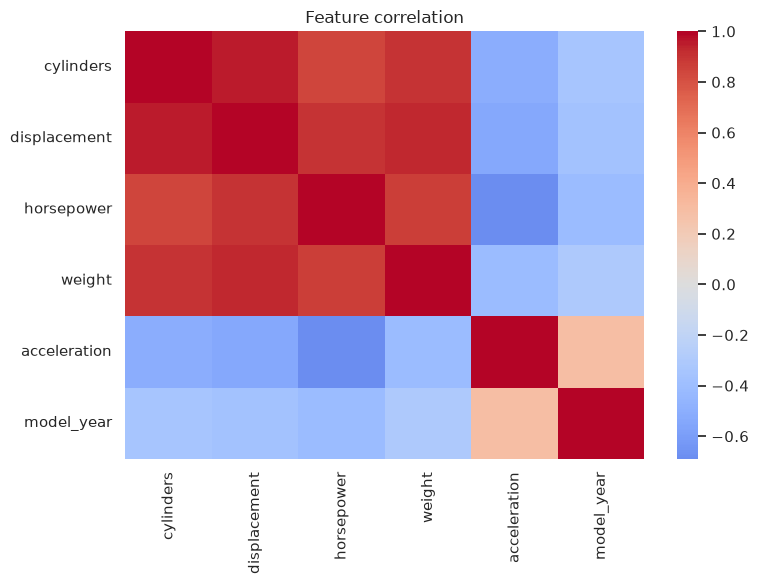

In [19]:
fig_heatmap(mpg_df, exclude=[MPG_TARGET])

### A14 — Bivariate: `numeric_vs_target()` + `categorical_vs_target()`

In [20]:
print(numeric_vs_target(mpg_df, MPG_TARGET, mpg_task).round(3).to_string())
display(categorical_vs_target(mpg_df, "origin", MPG_TARGET, mpg_task))

weight         -0.832
displacement   -0.804
horsepower     -0.778
cylinders      -0.775
model_year      0.579
acceleration    0.420


,mean,count
origin,,
usa,20.084,249
europe,27.891,70
japan,30.451,79


### A15 — Gates: `quality_flags()`

In [21]:
print(json.dumps(quality_flags(mpg_df, target=MPG_TARGET, task=mpg_task,
      leak=leakage_suspects(ct), pairs=multicollinear_pairs(mpg_df, exclude=[MPG_TARGET])), indent=2, default=str))

{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [
    [
      "cylinders",
      "displacement",
      0.951
    ],
    [
      "cylinders",
      "horsepower",
      0.843
    ],
    [
      "cylinders",
      "weight",
      0.896
    ],
    [
      "displacement",
      "horsepower",
      0.897
    ],
    [
      "displacement",
      "weight",
      0.933
    ],
    [
      "horsepower",
      "weight",
      0.865
    ]
  ],
  "task": "regression",
  "target": "mpg"
}


## Dataset B — Penguins (3-class classification, real missing values)
Identical calls, classification outputs.

### B1 — Profile + missing

In [22]:
display(column_profile(penguins_df))
display(missing_summary(penguins_df))

,dtype,pct_missing,n_unique,is_constant,is_id_like
species,str,0.00,3,False,False
island,str,0.00,3,False,False
bill_length_mm,float64,0.58,165,False,False
bill_depth_mm,float64,0.58,81,False,False
flipper_length_mm,float64,0.58,56,False,False
body_mass_g,float64,0.58,95,False,False
sex,str,3.20,3,False,False


,pct_missing,n_missing
sex,3.20,11
bill_length_mm,0.58,2
bill_depth_mm,0.58,2
flipper_length_mm,0.58,2
body_mass_g,0.58,2


### B2 — Missing chart

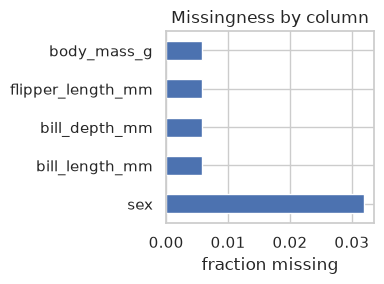

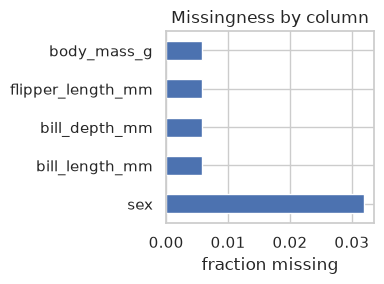

In [23]:
fig_missing_bar(penguins_df)

### B3 — Task + target distribution

task: classification {'imbalance_ratio': 2.24, 'minority_share': 0.1977, 'class_share': {'Adelie': 0.4419, 'Gentoo': 0.3605, 'Chinstrap': 0.1977}}


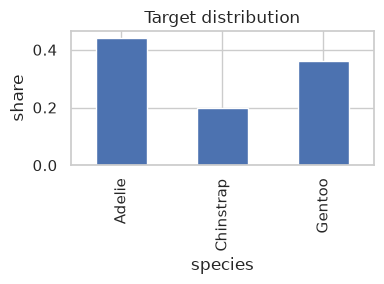

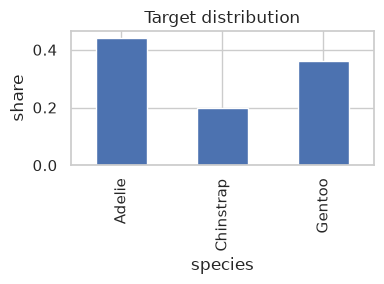

In [24]:
peng_task = detect_task(penguins_df[PENGUINS_TARGET], has_time=False)
print("task:", peng_task, target_stats(penguins_df[PENGUINS_TARGET], peng_task))
fig_target_distribution(penguins_df[PENGUINS_TARGET], peng_task)

### B4 — Categoricals + encoding advice

In [25]:
print("categoricals:", categorical_columns(penguins_df, target=PENGUINS_TARGET))
for c in categorical_columns(penguins_df, target=PENGUINS_TARGET):
    print(f"--- {c} ---")
    print(categorical_top(penguins_df, c).to_string())
    print("advice:", encoding_advice(penguins_df, c))

categoricals: ['island', 'sex']
--- island ---
island
Biscoe       0.4884
Dream        0.3605
Torgersen    0.1512
advice: low cardinality: one-hot encoding is fine
--- sex ---
sex
MALE      0.4884
FEMALE    0.4797
NaN       0.0320
advice: low cardinality: one-hot encoding is fine


### B5 — Numeric means by species

In [26]:
display(numeric_vs_target(penguins_df, PENGUINS_TARGET, peng_task))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791,18.346,189.954,3700.662
Chinstrap,48.834,18.421,195.824,3733.088
Gentoo,47.505,14.982,217.187,5076.016


### B6 — Island x species crosstab

In [27]:
display(categorical_vs_target(penguins_df, "island", PENGUINS_TARGET, peng_task))
print("-> Adelie/Torgersen vs Chinstrap/Dream: island nearly separates species — strong, legitimate signal.")

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,0.262,0.000,0.738
Dream,0.452,0.548,0.000
Torgersen,1.000,0.000,0.000


-> Adelie/Torgersen vs Chinstrap/Dream: island nearly separates species — strong, legitimate signal.


### B7 — Correlations + heatmap

flipper_length_mm    0.854
body_mass_g          0.750
bill_depth_mm       -0.744
bill_length_mm       0.731
leakage suspects: []


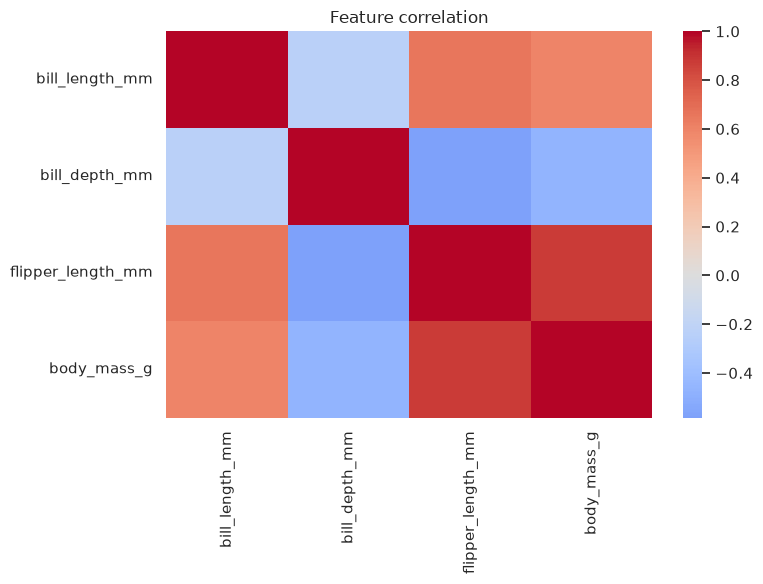

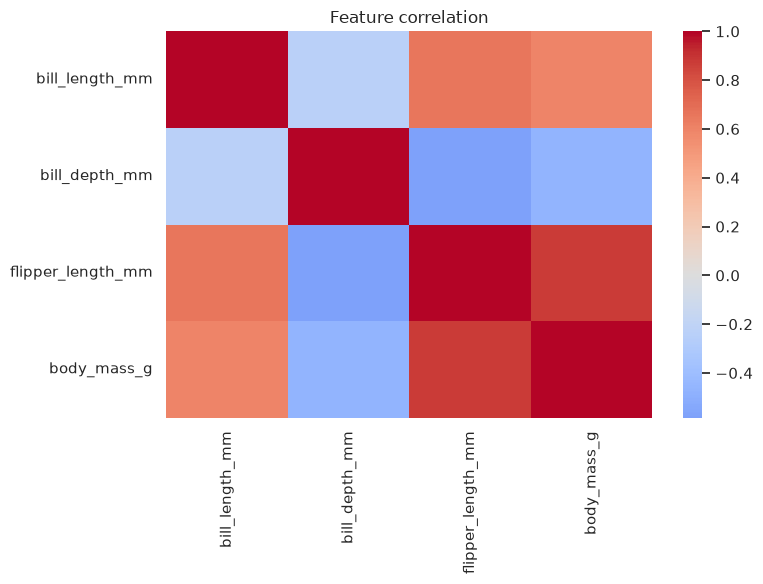

In [28]:
pct = target_correlations(penguins_df, PENGUINS_TARGET, peng_task)
print(pct.round(3).head(8).to_string())
print("leakage suspects:", leakage_suspects(pct))
fig_heatmap(penguins_df, exclude=[PENGUINS_TARGET])

### B8 — Gates

In [29]:
print(json.dumps(quality_flags(penguins_df, target=PENGUINS_TARGET, task=peng_task,
      leak=leakage_suspects(pct)), indent=2, default=str))
print("-> Say: stratify splits 3 ways; report weighted F1, not accuracy.")

{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [],
  "task": "classification",
  "target": "species"
}
-> Say: stratify splits 3 ways; report weighted F1, not accuracy.


## Dataset C — Sunspots (monthly 1749-1983, time-aware regression)
Same battery plus the datetime functions.

### C1 — Profile (note: Month is an object col)

In [30]:
display(column_profile(sunspots_df))
print("missing:", missing_summary(sunspots_df).shape[0], "cols")

,dtype,pct_missing,n_unique,is_constant,is_id_like
Month,str,0.0,2820,False,True
Sunspots,float64,0.0,1140,False,False


missing: 0 cols


### C2 — Datetime detection: `detect_datetime_columns()`

In [31]:
print("datetime cols:", detect_datetime_columns(sunspots_df))
print(datetime_summary(sunspots_df, SUNSPOTS_DATE))

datetime cols: ['Month']
{'min': Timestamp('1749-01-01 00:00:00'), 'max': Timestamp('1983-12-01 00:00:00'), 'n_nat': 0, 'median_gap': Timedelta('31 days 00:00:00'), 'max_gap': Timedelta('31 days 00:00:00'), 'inferred_freq': 'MS'}


### C3 — Volume over time: `volume_trend()`

t
1749-01-31    1
1749-02-28    1
1749-03-31    1
Freq: ME 
...


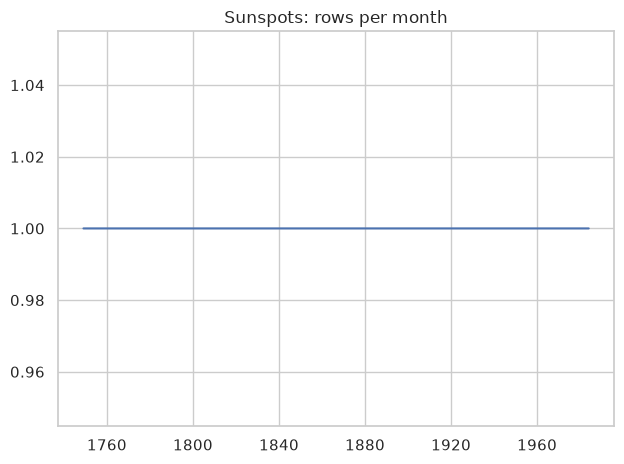

-> Unbroken monthly coverage for 230+ years — no gaps to worry about.


In [32]:
trend = volume_trend(sunspots_df, SUNSPOTS_DATE)
print(trend.head(3).to_string(), "\n...")
plt.figure(); plt.plot(trend.index, trend.values); plt.title("Sunspots: rows per month")
plt.tight_layout(); plt.show()
print("-> Unbroken monthly coverage for 230+ years — no gaps to worry about.")

### C4 — Task (time-aware) + target

task: regression+time {'skew': 1.101, 'kurt': 0.983, 'zero_share': 0.0238}


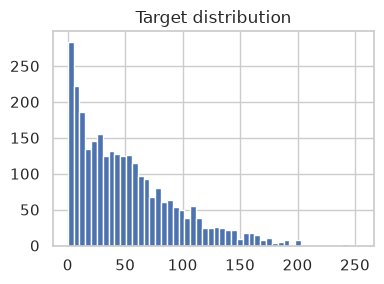

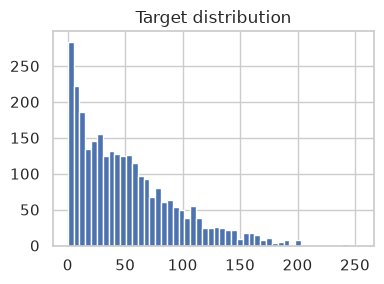

In [33]:
sun_task = detect_task(sunspots_df[SUNSPOTS_TARGET], has_time=True)
print("task:", sun_task, target_stats(sunspots_df[SUNSPOTS_TARGET], sun_task))
fig_target_distribution(sunspots_df[SUNSPOTS_TARGET], sun_task)

### C5 — Target over time (the money chart for series)

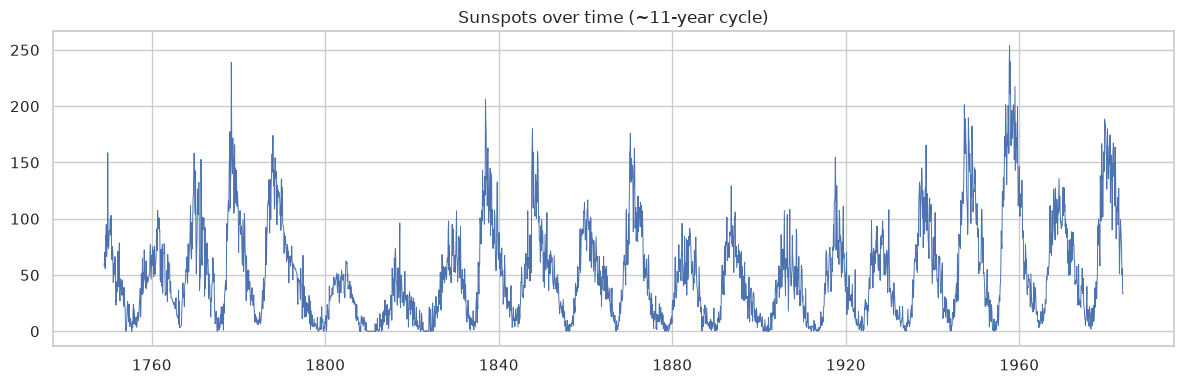

-> Say: clear ~11y cycle + trend; split chronologically, engineer lags on shift(1).


In [34]:
ts = pd.DataFrame({"t": pd.to_datetime(sunspots_df[SUNSPOTS_DATE]),
                 "y": pd.to_numeric(sunspots_df[SUNSPOTS_TARGET])}).dropna().sort_values("t")
plt.figure(figsize=(12, 4)); plt.plot(ts["t"], ts["y"], lw=0.7)
plt.title("Sunspots over time (~11-year cycle)"); plt.tight_layout(); plt.show()
print("-> Say: clear ~11y cycle + trend; split chronologically, engineer lags on shift(1).")

### C6 — Histograms + outliers

outliers: {}


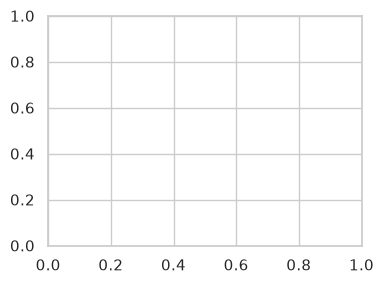

In [35]:
fig_histograms(sunspots_df, exclude=[SUNSPOTS_TARGET])
print("outliers:", outlier_shares(sunspots_df, exclude=[SUNSPOTS_TARGET]))

### C7 — Gates

In [36]:
print(json.dumps(quality_flags(sunspots_df, target=SUNSPOTS_TARGET, task=sun_task), indent=2, default=str))
print("-> Say: trees can't extrapolate trend — add trend feature or try boosting.")

{
  "dup_pct": 0.0,
  "constant": [],
  "id_like": [
    "Month"
  ],
  "missing_gt30": [],
  "leak_suspects": [],
  "multicollinear": [],
  "task": "regression+time",
  "target": "Sunspots"
}
-> Say: trees can't extrapolate trend — add trend feature or try boosting.


## 4 — Your own data
One task: copy this cell, point at your dataframe.

In [37]:
# df = pd.read_csv("my_data.csv")  # or: df = <your existing dataframe>
# findings = run_universal_eda(df, target="my_target", date="my_date_col", id_cols=("id",))
# print(findings["task"], findings["flags"])
print("uncomment the three lines above with your data — every function above works on any dataframe")

uncomment the three lines above with your data — every function above works on any dataframe


## 5 — Export
One task: save one JSON profile per showcase dataset.

In [38]:
from ml_boilerplate.eda import profile_dataframe
_root = repo_root()
(_root / "artifacts").mkdir(exist_ok=True)
for _name, _df in [("mpg", mpg_df), ("penguins", penguins_df), ("sunspots", sunspots_df)]:
    _p = _root / "artifacts" / f"eda_universal_profile_{_name}.json"
    _p.write_text(json.dumps(profile_dataframe(_df), indent=2, default=str))
    print("saved", _p)

saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_mpg.json
saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_penguins.json
saved /home/rajindersingh/personal_work/ml_boiler_plate/artifacts/eda_universal_profile_sunspots.json


### Next steps
- Modelling: `notebooks/library_usage.ipynb` or the CLI (`--config … train`).
- Functions reference: `src/ml_boilerplate/eda_universal.py` (every function has a docstring; tests in `tests/test_eda_universal.py`).
- This notebook is **read-only on data** — diagnosis only.